# The Monday Effect
### Is Monday still the market worst day, or did that ghost die decades ago?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Monday Effect still there?: Busted](https://img.shields.io/badge/Monday_Effect_still_there%3F-Busted-8b949e?style=flat-square)


For decades the folklore has said Monday is the worst trading day -- the
*Monday Effect* -- so you should avoid it. We measure the average close-to-close
return on each weekday of SPY (dividends included) and ask: is Monday really
negative? (**No**). Could you trade around it? (**No**).

> This is the plain-language layer. HAC t-stats and the pre/post-2000 split are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Not investment advice. Educational, reproducible research.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from monday_effect import data, strategy

AS_OF = "2026-06-16"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
wm = strategy.weekday_means(close)
bh = strategy.buy_and_hold(close)
mon_only = strategy.backtest(close, strategy.monday_only_position(close), cost_bps=1.0)
skip_mon = strategy.backtest(close, strategy.skip_monday_position(close), cost_bps=1.0)
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(wm.round(2))

SPY total return: 8,401 rows  1993-01-29 -> 2026-06-16  fingerprint=b8fb5124747e
     mean_bps         n  hac_t
Mon     5.640 1,578.000  2.060
Tue     7.260 1,726.000  2.670
Wed     6.200 1,723.000  2.210
Thu     1.460 1,690.000  0.520
Fri     3.320 1,683.000  1.330


## The answer first

| Question | Answer |
|---|---|
| Is Monday negative? | **No** -- Monday averages **+5.64 bps**, positive. |
| Weakest day? | **Thursday** (+1.46 bps). |
| Can you trade around it? | **No** -- buy-Monday earns **1.34%/yr** vs **10.82%/yr** B&H (**9 pts/yr less**). |

## 1 -- The claim

Kenneth French (1980) found significantly negative Monday close-to-close returns
on 1953-1977 S&P data. The question is whether it survived decades of arbitrage.

## 2 -- The teardown

First, the bar chart of weekday returns.

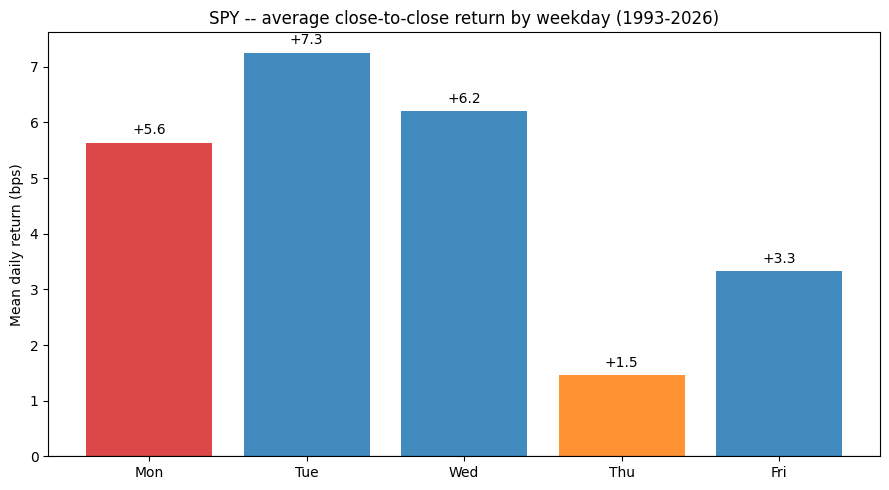

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['C3' if d=='Mon' else ('C1' if d=='Thu' else 'C0') for d in wm.index]
ax.bar(wm.index, wm['mean_bps'], color=colors, alpha=.85)
ax.axhline(0, color='k', lw=.8)
for d, v in wm['mean_bps'].items():
    ax.text(d, v + .15, f'{v:+.1f}', ha='center', fontsize=10)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title('SPY -- average close-to-close return by weekday (1993-2026)')
plt.tight_layout(); plt.show()

**Monday (red) is positive** (+5.64 bps). Thursday (orange) is weakest (+1.46 bps). All days positive -- the negative-Monday effect is gone.

Now the tradability test: literal rules vs holding SPY.

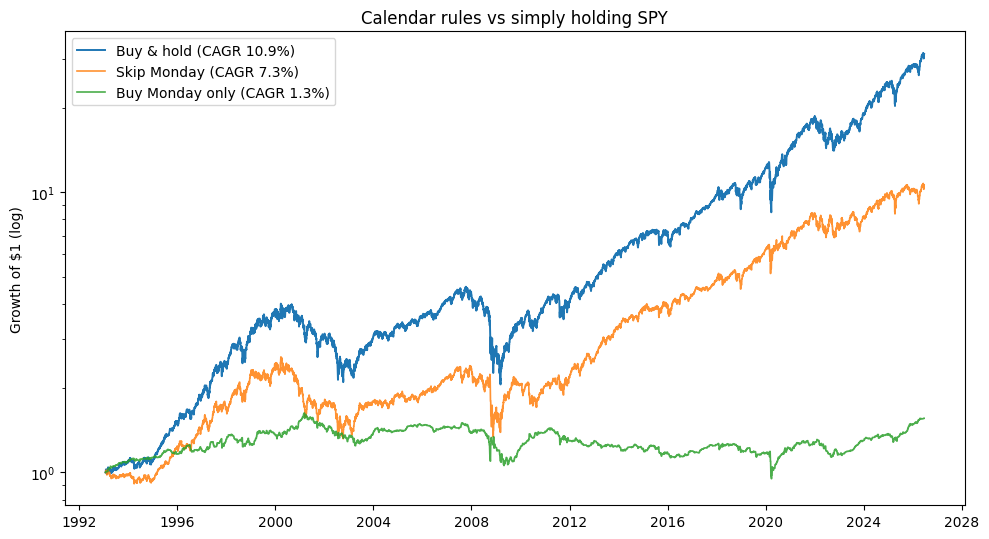

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(bh['equity'], label=f"Buy & hold (CAGR {bh['cagr']*100:.1f}%)", lw=1.4)
ax.plot(skip_mon['equity'], label=f"Skip Monday (CAGR {skip_mon['cagr']*100:.1f}%)", lw=1.2, alpha=.85)
ax.plot(mon_only['equity'], label=f"Buy Monday only (CAGR {mon_only['cagr']*100:.1f}%)", lw=1.2, alpha=.85)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.legend()
ax.set_title('Calendar rules vs simply holding SPY')
plt.tight_layout(); plt.show()

Not close. Buy-Monday: 1.34%/yr vs 10.82%/yr B&H
(**9 pts/yr lost** sitting in cash 81% of time).
Skip-Monday: 7.3%/yr (4 pts/yr lost).
Avoiding a positive day costs you the equity premium.

## 3 -- The verdict

- **Monday Effect still there? Busted.** Monday is +5.64 bps, positive pre- and post-2000.
- **Signal -- None.** Monday-rest +1.08 bps (HAC t +0.36): wrong sign.
- **Trade it? Mirage.** Buy-Monday -9 pts/yr, skip-Monday -4 pts/yr vs B&H.

## 4 -- Going further

- Extend to **^GSPC** 1950s data (price-only) to find when the effect vanished.
- Is there a *Monday-after-down-Friday* conditional effect?
- International evidence in markets with less arbitrage capacity?